# Module 2: Epidemic Modeling

## Team Members:
Sara Elster, Dani Folks

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

First, we imported the libraries necessary for computation and loaded the data from release 1.

In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Load the data
data = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

Next, we used the Scipy curve_fit function to estimate R0 from the data.

In [3]:
# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data. 
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.
x_data = data['day'].values.astype(float)
y_data = data['active reported daily cases'].values.astype(float)
popt, pcov = curve_fit(exponential_growth, x_data, y_data)

r_fit = popt[0]

# Approximate R0 using this fit
D = 6 # It seems from the data that there is a 6 day infectious period

r0 = np.exp(r_fit * D)

print("Estimated growth rate R0: ", r0)

Estimated growth rate R0:  2.07234440971209


Finally, we added the fitted exponential curve to the actual virus data to see whether it was a good estimate.

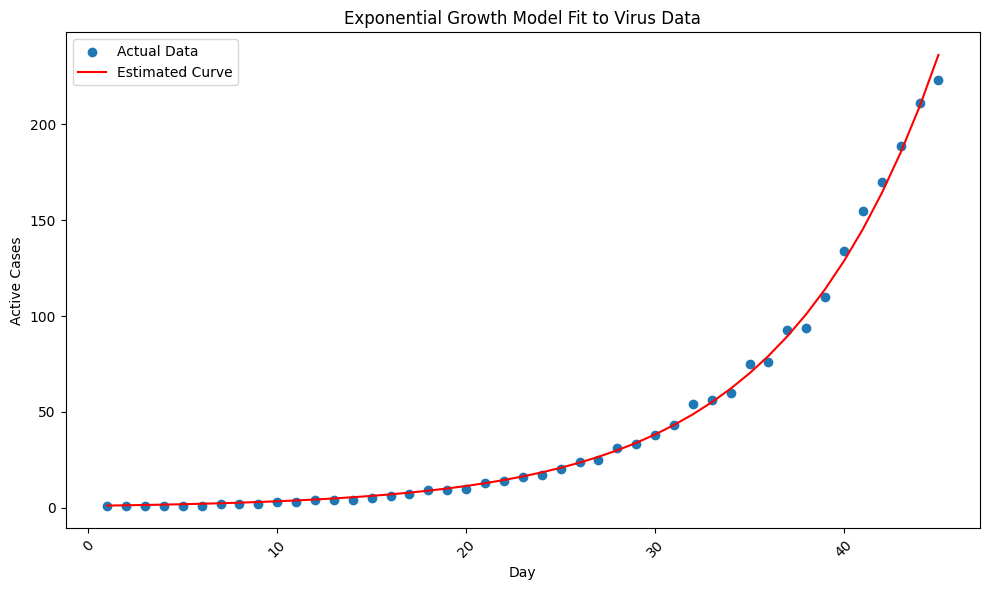

In [4]:
# Add the fit as a line on top of your scatterplot.
# Generate fitted curve
y_fitted = exponential_growth(x_data, r_fit)

# Plot fitted curve and actual data
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label = "Actual Data")
plt.plot(x_data, y_fitted, color = "red", label = "Estimated Curve")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Growth Model Fit to Virus Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show() 

##### Preliminary Analysis/Conclusions:

**Analysis of Data Release 1:**
1. **What do you notice about initial infections?**

The initial infections seem to be very low, with only a few cases reported in the early days. This could indicate that the virus was not spreading widely at the beginning, or that there was limited testing and reporting.

2. **How could we measure how quickly its spreading?**

We could measure how quickly the virus is spreading by calculating the growth rate of active cases over time. This can be done by taking the difference in active cases between consecutive days and dividing it by the number of active cases on the previous day to get a percentage growth rate. 

3. **What information about the virus would be helpful in determining the shape of the outbreak curve?**

Information about the virus's transmission rate, incubation period, and recovery time would be helpful in determining the shape of the outbreak curve.


**From viruses.html:**
Mumps and chickenpox both have R0 values of 10. Mumps is a contagious disease caused by a virus that affects the salivary glands. It is spread through saliva and respiratory droplets (coughing/sneezing), and causes painful swelling of the salivary glands. Chickenpox is caused by the varicella-zoster virus and is spread through coughing, sneezing, and contact with chickenpox blister fluid. Symptoms include fever, fatigue, itchy rashes that turn into fluid filled blisters that scab over. Both diseases are highly contagious due to their easy transmission, explaining the high R0 value.

**How accurate do you think your R0 value is?**

Generally, we believe our R0 estimate is accurate. However, we are unsure of how to calculate D, so we guessed from observing the data that the infectious period was 6 days.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

First, we imported the necessary libraries.

In [5]:
#%% SEIR model fitting with Euler's method
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Next, we pulled the dataset from Data Release 2 and organized the days and cases into their own data sets.

In [6]:
# Helper: safely find data columns

data = pd.read_csv(r"/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)

possible_day_cols = ['day', 'day_number', 'Day', 'Day Number']
possible_case_cols = ['active_cases', 'active case', 'active', 'cases', 'Active Cases']

day_col = None
case_col = None

for col in data.columns:
    if col in possible_day_cols:
        day_col = col
    if col in possible_case_cols:
        case_col = col

# fallback: try lowercase matching
if day_col is None:
    for col in data.columns:
        if 'day' in col.lower():
            day_col = col
            break

if case_col is None:
    for col in data.columns:
        c = col.lower()
        if 'active' in c or 'case' in c:
            case_col = col
            break

if day_col is None or case_col is None:
    raise ValueError(f"Could not find required columns. Columns found: {list(data.columns)}")

timepoints = data[day_col].to_numpy()
infected_data = data[case_col].to_numpy()


Finally, we used Euler's method to approximate S, E, I, and R parameters of SEIR model.

In [7]:
# Initial conditions
N = 10000           # total population
I0 = infected_data[0]
E0 = I0             # reasonable first guess: exposed starts similar to infected
R0_init = 0         # initial recovered is 0
S0 = N - E0 - I0 - R0_init

# Euler method for SEIR
def euler_seir(timepoints, N, S0, E0, I0, R0, beta, sigma, gamma):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for i in range(len(timepoints) - 1):
        dSdt = -beta * S[i] * I[i] / N
        dEdt = beta * S[i] * I[i] / N - sigma * E[i]
        dIdt = sigma * E[i] - gamma * I[i]
        dRdt = gamma * I[i]

        S[i + 1] = S[i] + dSdt * dt
        E[i + 1] = E[i] + dEdt * dt
        I[i + 1] = I[i] + dIdt * dt
        R[i + 1] = R[i] + dRdt * dt

    return S, E, I, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

First, we used SSE to determine the optimal values for beta, sigma, and gamma, and the corresponding SSE.

In [8]:
# SSE calculation
def calculate_sse(model_I, data_I):
    return np.sum((model_I - data_I) ** 2)

# Parameter search
def fit_seir_parameters(timepoints, N, S0, E0, I0, R0, infected_data):
    # These are reasonable starter ranges for a daily-timescale outbreak
    beta_values = np.linspace(0.1, 1.2, 30)
    sigma_values = np.linspace(0.05, 0.6, 25)
    gamma_values = np.linspace(0.05, 0.6, 25)

    best_sse = np.inf
    best_beta = None
    best_sigma = None
    best_gamma = None

    sse_results = []

    for b in beta_values:
        for s in sigma_values:
            for g in gamma_values:
                S, E, I, R = euler_seir(timepoints, N, S0, E0, I0, R0, b, s, g)
                sse = calculate_sse(I, infected_data)
                sse_results.append((b, s, g, sse))

                if sse < best_sse:
                    best_sse = sse
                    best_beta = b
                    best_sigma = s
                    best_gamma = g

    return best_beta, best_sigma, best_gamma, best_sse, sse_results

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Finally, we ran the calculations and plotted the corresponding best fit model with the actual data.

Best beta = 0.25172413793103443
Best sigma = 0.4854166666666666
Best gamma = 0.07291666666666667
Best SSE = 73865.90060900546


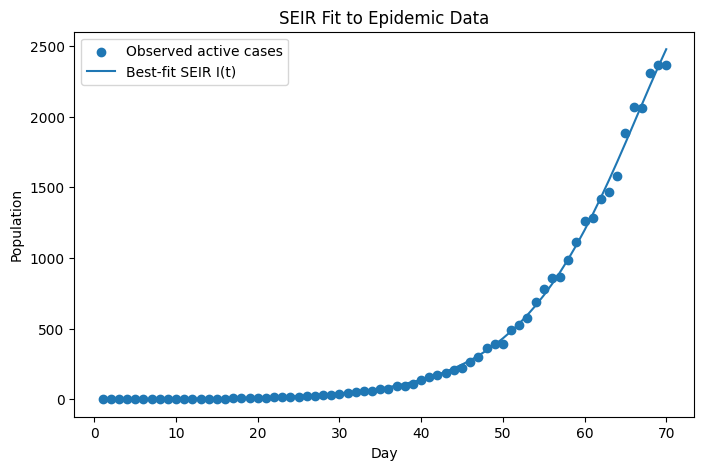

In [9]:
# Fit the model
best_beta, best_sigma, best_gamma, best_sse, sse_results = fit_seir_parameters(
    timepoints, N, S0, E0, I0, R0_init, infected_data
)

print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Best SSE =", best_sse)

# Run best-fit model on observed time window
S_fit, E_fit, I_fit, R_fit = euler_seir(
    timepoints, N, S0, E0, I0, R0_init,
    best_beta, best_sigma, best_gamma
)

# Plot model fit vs data
plt.figure(figsize=(8, 5))
plt.scatter(timepoints, infected_data, label='Observed active cases')
plt.plot(timepoints, I_fit, label='Best-fit SEIR I(t)')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Fit to Epidemic Data')
plt.legend()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.

To predict the peak and plot the predicted graph, we calculated future timepoints until day 200 using the approximated S, E, I, and R values. Then, we used these values to predict what the peak number of cases would be and the corresponding day.

In [10]:
# Predict the future peak
future_days = 120
future_timepoints = np.arange(timepoints[0], timepoints[0] + future_days + 1, 1)

S_future, E_future, I_future, R_future = euler_seir(
    future_timepoints, N, S0, E0, I0, R0_init,
    best_beta, best_sigma, best_gamma
)

peak_index = np.argmax(I_future)
peak_day = future_timepoints[peak_index]
peak_value = I_future[peak_index]

print("Predicted peak infected population =", peak_value)
print("Predicted peak day =", peak_day)


Predicted peak infected population = 3123.4507617445415
Predicted peak day = 79


Finally, we used the predicted data to plot the predicted graph of number of cases vs days as well as the peak number of cases and days.

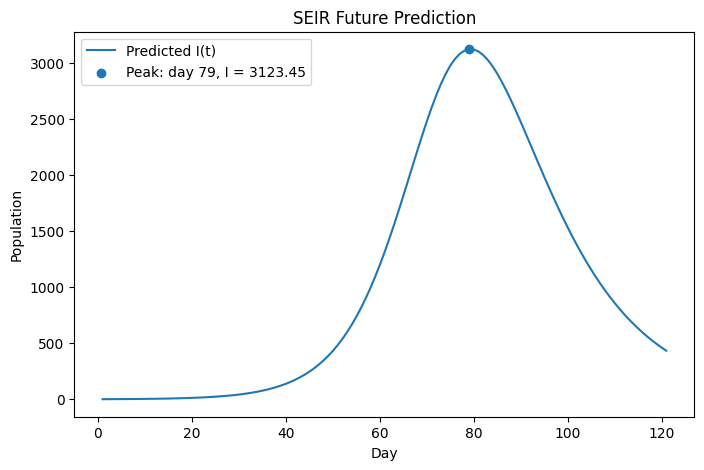

In [11]:
# Plot future prediction
plt.figure(figsize=(8, 5))
plt.plot(future_timepoints, I_future, label='Predicted I(t)')
plt.scatter(peak_day, peak_value, label=f'Peak: day {peak_day}, I = {peak_value:.2f}')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Future Prediction')
plt.legend()
plt.show()

#### Calculating True % Relative Error:
Actual Peak (based on Data Release 3): 3294 cases, on Day 83
1. For peak # of cases: % error = 5.178%
2. For peak day: % error = 4.819%


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.

First, we loaded the actual data from data release 3.


In [12]:
# Loading data from data release 3
data_3 = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)

x_data_actual = data_3['day'].values.astype(float)
y_data_actual = data_3['active reported daily cases'].values.astype(float)

Once the data was loaded, we were able to plot the actual data with the predicted curve.

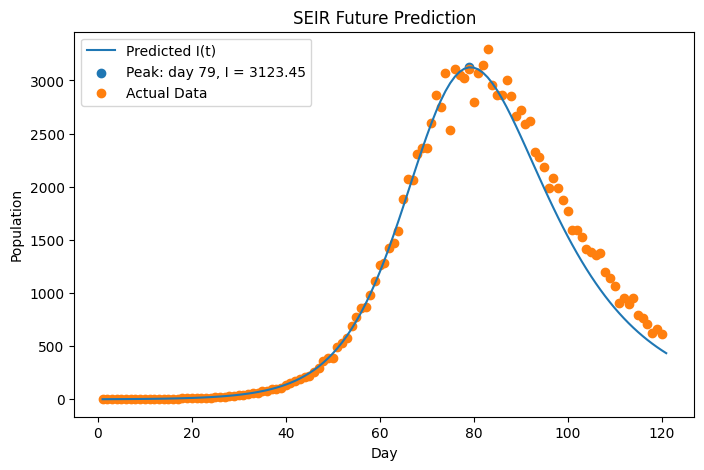

In [13]:
# Plotting full dataset against SEIR model
plt.figure(figsize=(8, 5))
plt.plot(future_timepoints, I_future, label='Predicted I(t)')
plt.scatter(peak_day, peak_value, label=f'Peak: day {peak_day}, I = {peak_value:.2f}')
plt.scatter(x_data_actual, y_data_actual, label = "Actual Data")
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Future Prediction')
plt.legend()
plt.show()

Finally, we calculated both the true and relative error for both the predicted peak number of cases and peak day of infection. To do this, we iterated through data set 3 to find the actual peak number of cases and corresponding day, then calculated the true and relative errors based off of these numbers.

In [14]:
# Estimating error

# Finding actual peak value and day from data release 3
actual_peak_value = 0
actual_peak_day = 0
for num in range(len(y_data_actual)):
    if y_data_actual[num] > actual_peak_value:
        actual_peak_value = y_data_actual[num]
        actual_peak_day = x_data_actual[num]

# Calculating true error for value and day
true_error_value = actual_peak_value - peak_value
true_error_day = actual_peak_day - peak_day
print("True error for peak number of cases:", round(true_error_value, 2))
print("True error value for peak day:", true_error_day)

# Calculating percent error
rel_error_value = (true_error_value/actual_peak_value)*100
rel_error_day = (true_error_day/actual_peak_day)*100
print("Relative (%) error for peak number if cases: " + str(round(rel_error_value, 2)) + "%")
print("Relative (%) error for peak day: " + str(round(rel_error_day, 2)) + "%")

True error for peak number of cases: 170.55
True error value for peak day: 4.0
Relative (%) error for peak number if cases: 5.18%
Relative (%) error for peak day: 4.82%


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.

The intervention strategies we modeled were masking mandates, testing/quarantine starting at day 70, and closing school for two weeks.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*